# Przewidywanie grup Pokemonów
## Autorzy
- Alicja Knigawka 230979
- Dominik Miernik 230984
- Karolina Kaleta 227850
- Mariusz Jakoniuk 227762
- Urszula Solan 227699
## Słowa kluczowe
Pokemon, drzewa decyzyjne, drzewo decyzyjne, indeks Giniego, klasyfikacja wieloklasowa, las losowy, macierz pomyłek, podział rekurencyjny, random forest, regresja logistyczna, regresja logistyczna wieloklasowa, softmax, standaryzacja danych, walidacja krzyżowa,

## 1. Wprowadzenie
Seria gier Pokemon jest jedną z najpopularniejszych franczyz wyprodukowanych do tej pory.
W grach ziemię, oprócz ludzi, zamieszkują stworki nazywane "Pokemonami".
Mimo uroczego wyglądu, w świecie gier, Pokemony są przede wszystkim wykorzystywane do walk w brutalnych(pokroju walk psów).
Każdy Pokemon posiada jeden bądź dwa "typy", które wpływają na jego zdolności w walce (np. Pokemon typu "woda" będzie silny w walce przeciwko Pokemonowi typu "ogień").

Dane użyte w badaniu pochodzą z serwisu [Pokemon Database](https://pokemondb.net/), który udostępnia dane z najnowszego wydania gier w postaci pliku YAML. Plik został przez badaczy spłaszczony i przekonwertowany do formatu CSV.

## 2. Przedmiot i cel badania

W badaniu wykorzystano metody uczenia maszynowego (regresję logistyczną, drzewo decyzyjne, lasy losowe oraz model hybrydowy) do przyporządkowywania Pokemonów w pewne "grupy".
Każda grupa jest sumą kilku typów bądź pojedyńczym typem.
Dobór "grup" był arbitralny, badacze na podstawie subiektywnych doświadczeń z grami złączyli ze sobą typy, które z perspektywy gracza wydają się być do siebie "podobne".

W efekcie otrzymano grupy Pokemonów mających w walkach podobne role. Poszczególne grupy i ich cechy zostały omówione w rozdziale "Wstępna analiza danych".

W celu uproszczenia prezentacji danych, w badaniu zastosowano skróty nazw metod:
- **LR** - Regresja Logistyczna
- **RF** - Random Forest
- **DT** - Drzewo decyzyjne


### 2.1. Analiza literatury i wcześniejsze prace

Autorzy przeszukali dostępne zasoby w poszukiwaniu artykułów poruszających wybraną w badaniu tematykę. Mimo tego, że franczyza Pokemon jest częstym podmiotem analiz, to dotychczasowe badania skupiają się głównie na zagadnieniach bezpośrednio dotyczących gry (Mudireddy, Patibandla 2026; Pleines et al. 2025), a nie Pokemonów samych w sobie. Znaleziono jedno badanie (Kilpatrick, Ćwiek, Kawahara 2023), którego autorzy trenują drzewa losowe do przewidywania stadium ewolucji każdego Pokemona na podstawie jego nazwy.

## 3. Wstępna analiza danych

In [1]:
#Importy:
from pygments.styles import manni
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### 3.1. Przedstawienie dostępnych zmiennych
Do analizy wybraliśmy następujące cechy:
- `hp` - Maksymalny poziom zdrowia Pokemona (jak wiele punktów obrażeń Pokemon musi przyjąć podczas walki żeby zemdleć)
- `attack`- Ile obrażeń zadaje Pokemon wykonując ataki
- `defense` - Współczynnik zmniejszający otrzymywane obrażenia
- `spatk` - Współczynnik zwiększający zadawane obrażenia przy pomocy ataków specjalnych
- `spdef` - Współczynnik zmniejszający otrzymywane obrażenia od ataków specjalnych
- `speed` - Prędkość Pokemona, wpływa na kolejność tur w bitwie
- `height` - Wysokość Pokemona
- `weight` - Waga Pokemona
- `catch_rate` - Łatwość złapania Pokemona (im większa wartość, tym łatwiej złapać Pokemona)
- `base_exp` - Główny współczynnik określajacy ile punktow doświadczenia Pokemon otrzyma po zakończeniu walki
- `egg_cycle` - Ile kroków należy wykonać aby Pokemon się wykluł z jajka

Badane cechy można podzielić na 3 kategorie:
1. Mające wplyw na efektywność danego Pokemona w walce (`hp`, `attack`, `defense`, `spatk`, `spdef`, `speed`)
2. Określające trudnosć złapania lub rozwijania Pokemona (`catch_rate`, `egg_cycle`, `base_exp`)
3. Mające sens głównie kosmetyczny (`height`, `weight`)

In [2]:
pokemonyMain = pd.read_csv("pokemonyMain_groups.csv")

cechy_names = [
    "group",
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles"
]

cechy_names_without_group = cechy_names[1:]

cechy = pokemonyMain[cechy_names]
description = cechy .describe()
description.loc['skew'] = cechy.skew(numeric_only=True)
description


,hp,attack,defense,spatk,spdef,speed,height,weight,catch_rate,base_exp,egg_cycles
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1214.000000,1214.000000,1192.000000,1192.000000
mean,71.244444,81.152263,75.007407,73.224691,72.441152,70.034568,1.378354,73.883526,90.615321,159.199664,31.040268
std,26.927819,32.037134,30.740999,32.757152,27.578188,30.161298,3.150568,133.733048,75.330475,84.159281,29.139061
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,0.100000,0.100000,3.000000,36.000000,5.000000
25%,52.000000,57.000000,52.000000,50.000000,51.000000,45.000000,0.600000,9.000000,45.000000,68.000000,20.000000
50%,70.000000,80.000000,70.000000,65.000000,70.000000,68.000000,1.000000,30.000000,60.000000,162.000000,20.000000
75%,85.000000,100.000000,91.000000,95.000000,90.000000,91.000000,1.600000,76.375000,120.000000,215.250000,25.000000
max,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,100.000000,999.900000,255.000000,635.000000,120.000000
skew,1.606628,0.416642,1.104015,0.692224,0.871229,0.362885,25.748668,3.997218,0.975258,0.569060,2.473601


### 3.2. Podział Pokemonów na grupy
Każdy Pokemon ma przypisany do siebie pewien "typ" wpływający na efektywność w walce (np. ataki typu "woda" będą działały ze zwiększoną siłą przeciw Pokemonom typu "ogień"). Typy zachowujące się podobnie w grach zostały przez nas złączone w "grupy":
1. **Średniaki** (typy "water", "poison", "grass", "ice", "normal", "bug") - Pokemony "pospolite", cechujące się wszechstronnością i łatwością złapania.
2. **Grubole** ("ground", "rock", "steel") - Pokemony obronne, potrafiące przyjąć na siebie większą ilość obrażeń, jednocześnie nie uzyskując przy tym większych uszczerbków na zdrowiu
3. **Spejalni** ("electric", "psychic", "fairy", "ghost", "fire") - Pokemony specjalizujące się w walce z Pokemonami specifycznych typów (np. Pokemony typu "electric" specjalizują się w walce z Pokemonami typu "water")
4. **Agresorzy** ("fighting", "dark", "flying") - Pokemony ofensywne, atakujące szybko i zadające wysokie obrażenia
5. **Elita** ("dragon") - Typ "smok" został wydzielony do oddzielnej grupy. Smoki są najsilniejszymi Pokemonami, ale też najtrudniej jest je zdobyć.


Średnie wartości dla grup:

In [3]:
grouped_means = cechy.groupby("group").mean().copy()
grouped_means

,hp,attack,defense,spatk,spdef,speed,height,weight,catch_rate,base_exp,egg_cycles
group,,,,,,,,,,,
agresorzy,73.948276,93.568966,73.025862,64.922414,70.198276,77.724138,1.277586,75.825000,81.879310,164.991379,34.870690
elita,84.571429,103.816327,80.816327,90.122449,83.571429,84.653061,2.038776,121.132653,38.408163,217.265306,63.163265
grubole,70.675000,92.193750,99.012500,64.125000,72.725000,59.756250,1.560625,155.336875,80.512500,163.269231,34.198718
specjalni,68.974194,76.203226,70.825806,88.867742,77.893548,76.580645,1.190323,62.331290,81.864516,170.753247,35.454545
sredniaki,70.948276,76.353448,70.525862,67.606897,68.956897,66.598276,1.392931,53.172366,104.260794,145.504440,24.165187


Poniżej przedstawiono wykres radarowy średnich wartości cech dla każdej ze zdefiniowanych grup. Wartości na wykresach zostały zeskalowane korzystając ze wzoru $z_{ij} = \frac{x_{ij}}{\max(x_i)}$

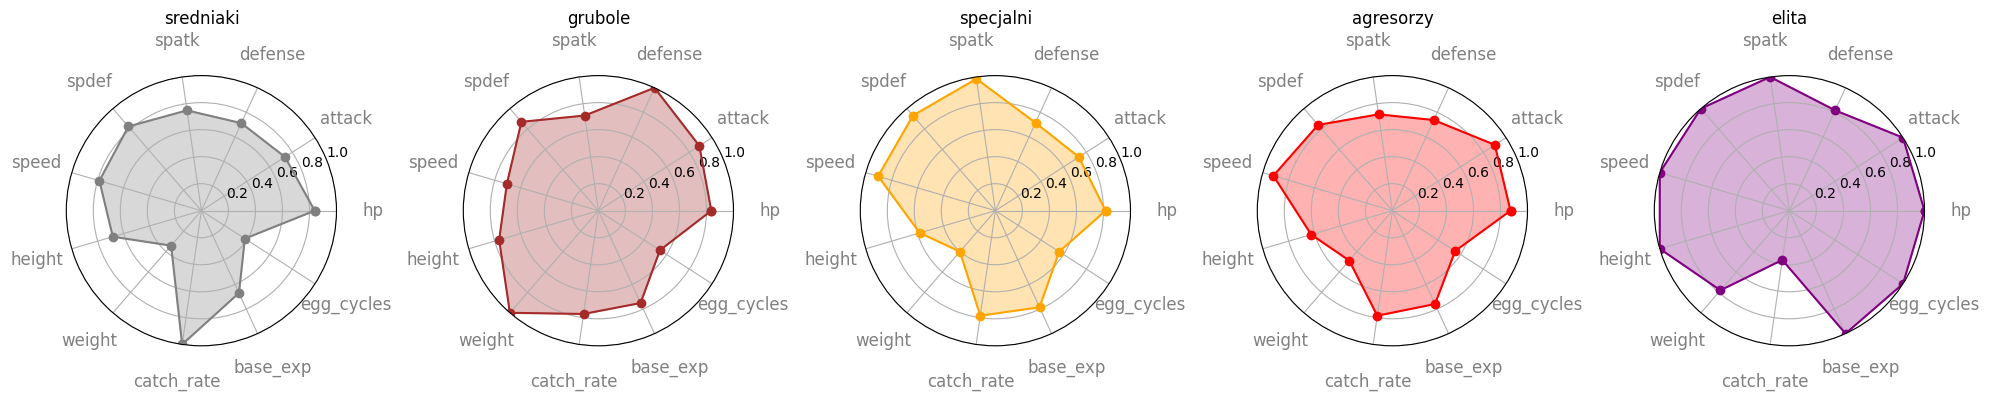

In [4]:
normalized = grouped_means / grouped_means.max().abs()

def radar(ax, group: str, color: str):
    theta = np.arange(len(grouped_means.columns) + 1) / float(len(grouped_means.columns)) * 2 * np.pi
    values = normalized.loc[group].values
    values = np.append(values, values[0])

    ax.plot(theta, values, color=color, marker="o", label="Name of Col B")
    ax.fill(theta, values, color=color, alpha=0.3)
    ax.set_ylim(0, 1)

    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(grouped_means.columns, color='grey', size=12)
    ax.tick_params(pad=16)
    ax.set_title(group)

fig, axes = plt.subplots(nrows = 1, ncols = 5, subplot_kw={'projection': 'polar'}, figsize=(20, 20))

color_mapping = [
    ('sredniaki', 'gray'),
    ('grubole', 'brown'),
    ('specjalni', 'orange'),
    ('agresorzy', 'red'),
    ('elita', 'purple'),
]

for ax, (group, color) in zip(axes, color_mapping):
    radar(ax, group, color)

plt.tight_layout()
plt.show()

### 3.3. Braki danych i pomiary odstające

Przed trenowaniem modeli, w zbiorze danych znaleziono i usunięto obiekty z brakami w badanych cechach.

In [5]:
original_count = len(pokemonyMain)
pokemonyMain = pokemonyMain.dropna(subset = cechy_names)
new_count = len(pokemonyMain)
print(f"Znaleziono {original_count - new_count} obiekty posiadające braki w badanych cechach")

Znaleziono 24 obiekty posiadające braki w badanych cechach


Odrzucono pomiary ze $z\text{-score} \lt 3$ dla dowolnej z badanych cech.

In [6]:
for col in cechy_names_without_group:
    z = np.abs(stats.zscore(pokemonyMain[col]))
    pokemonyMain = pokemonyMain[z < 3]


print(f"Pomiarów odstających: {new_count - len(pokemonyMain)}")
print(f"Ostateczna lizczba obiektów: {len(pokemonyMain)}")

Pomiarów odstających: 146
Ostateczna lizczba obiektów: 1045


## 4. Opis metod

Dane zostały podzielone na zbiór treningowy (70%) oraz testowy (30%) w celu oceny skuteczności modelu.

In [7]:
cechy = pokemonyMain[cechy_names_without_group]

etykieta = pokemonyMain["group"]

cecha_train, cecha_test, etykieta_train, etykieta_test = train_test_split(
    cechy,
    etykieta,
    test_size=0.3,
    random_state=42
)

### 4.1. Regresja Logistyczna

#### 4.1.1. Opis metody regresji logistycznej

Regresja logistyczna wieloklasowa jest modelem klasyfikacyjnym, który oblicza prawdopodobieństwo przynależności obserwacji do każdej z możliwych klas. Dla każdej klasy model wyznacza osobny zestaw wag, a następnie wykorzystuje funkcję softmax, aby zamienić wyniki na wartości z przedziału [0,1], których suma wynosi 1. Klasa o największym prawdopodobieństwie jest wybierana jako wynik predykcji.

Uczenie modelu polega na dopasowaniu wag w taki sposób, aby minimalizować błąd klasyfikacji na danych treningowych, zazwyczaj metodami gradientowymi.

Zastowaliśmy regresję logistyczną wieloklasową wraz ze standaryzacją danych.

W regresji logistycznej wieloklasowej prawdopodobieństwo przynależności do obserwacji do klasy $k$ wyznaczane jest za pomocą funkcji softmax:
$$
P(y=k|x)=\frac{e^{z_k}}{\sum_{j=1}^{5} e^{z_j}}
$$

gdzie:
- $P(y=k|x)$ - prawdopodobieństwo przypisania obserwacji do klasy $k$,
-  $z_k$ - wynik modelu dla klasy $k$,
- mianownik stanowi sumę wyników dla wszystkich 5 klas.

In [8]:
modelRegresja = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, solver="lbfgs"))

#### 4.1.2. Trenowanie modelu regresji logistycznej
Model regresji logistycznej został wytrenowany na przygotowanych danych treningowych. W procesie uczenia model dobiera swoje parametry w taki sposób, aby najdokładniej przypisywać obserwacje do odpowiednich klas. Przed wytrenowaniem dane zostały wystadaryzowane, co pozwoliło poprawić skuteczność działania modelu.


In [9]:
modelRegresja.fit(cecha_train, etykieta_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

### 4.2 Drzewa decyzyjne

#### 4.2.1. Opis metody drzewa decyzyjnego

Model drzewa decyzyjnego polega na rekurencyjnym podziale przestrzeni cech. W każdym kroku wybierana jest zmienna i punkt podziału, które najlepiej separuja klasy danych.

Celem jest minimalizacja miary niejednorodności, np. indeksu Giniego:
$$G=1-\sum_{k=1}^{K}p_{k}^{2},$$
gdzie $p_{k}$ oznacza udział obserwacji z klasy k w danym weźle drzewa.

Ostateczna predykcja wykonywana jest poprzez przypisanie obserwacji do odpowiedniego liścia drzewa decyzyjnego. Zaletą tego modelu jest wysoka interpretowalność i brak konieczności wstępnego skalowania danych.

#### 4.2.2. Trenowanie modelu drzewa decyzyjnego

In [10]:
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=2,
    random_state=42)
tree_model.fit(cecha_train, etykieta_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### 4.3. Random Forest

#### 4.3.1. Opis metody lasu losowego
Las losowy (ang. Random Forest) to metoda polegająca na uśrednianiu wyników wielu głębokich drzew decyzyjnych, które są trenowane na różnych częściach tego samego zbioru treningowego. Głównym celem tego podejścia jest eliminacja problemu przeuczenia (ang. overfitting), który często występuje w przypadku pojedynczych drzew decyzyjnych.
Innymi słowy, lasy losowe stanowią metodę uczenia zespołowego (ang. ensemble learning) wykorzystywaną w zadaniach klasyfikacji i regresji. Algorytm ten działa poprzez konstruowanie wielu drzew decyzyjnych w fazie trenowania, a jego ostatecznym wynikiem w przypadku klasyfikacji jest klasa dominująca wśród wskazań uzyskanych z poszczególnych drzew.

 - Każde drzewo w lesie jest trenowane na podstawie około 2/3 wszystkich danych treningowych (dkładanie 63,2 %, ale u nas jest to 70%) Wybór przypadków jest losowy z wykorzystaniem oryginalnych danych. Ta próbka stanowi zbiór treningowy do rozbudowy drzewa.
 - Niektóre zmienne predykcyjne są losowo wybierane do rozważenia przy każdym podziale w drzewie. Zazwyczaj jest to pierwiastek kwadratowy z liczby wszystkich zmiennych predykcyjnych.
  - Dla kadego drzewa, wykorzystując pozostałe dane (36,8%, u nas dla uproszczenia 30 %) oblicza się wskaźnik błędu, który jest używany do oceny wydajności modelu (OOB).

   - Kazde drzewo klasyfikuje swoje dane OOB, a następnie porównuje przewidywania z rzeczywistymi etykietami, aby obliczyć wskaźnik błędu OOB. Ten wskaźnik jest używany do oceny wydajności modelu i może być wykorzystany do dostrajania hiperparametrów.

In [11]:
modelLas = RandomForestClassifier(n_estimators=100, random_state=42)

#### 4.3.2. Trenowanie modelu lasu losowego

Komenda `modelLas.fit()` odpowiada za przeprowadzenie właściwego procesu trenowania algorytmu Lasu Losowego na wyodrębnionym zbiorze treningowym (`cecha_train`, `etykieta_train`). Na tym etapie algorytm buduje strukturę złożoną ze 100 niezależnych drzew decyzyjnych, wykorzystując technikę agregacji bootstrapowej (Bagging) oraz losową selekcję cech w węzłach. Model analizuje korelacje pomiędzy parametrami numerycznymi obiektów a ich rzeczywistą przynależnością do klas, optymalizując wewnętrzne reguły podziału w celu zminimalizowania błędu klasyfikacji. Po wykonaniu tej operacji model uzyskuje zdolność do predykcji.

In [12]:
modelLas.fit(cecha_train, etykieta_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 4.4. Hybrydowe modele

#### 4.4.1. Opis metody
Hybryda to prosty model zespołowy, który łączy predykcje kilku klasyfikatorów poprzez uśrednianie prawdopodobieństw klas zwracanych przez predict_proba. W tym projekcie wykorzystano trzy modele: regresję logistyczną, las losowy oraz drzewo decyzyjne.

Dla każdej próbki obliczane jest średnie prawdopodobieństwo przynależności do każdej klasy, a następnie wybierana jest ta klasa, która uzyska najwyższą wartość średnią. Dzięki temu decyzja końcowa nie zależy od jednego modelu, lecz od wspólnego głosu.

Takie podejście ma kilka zalet. Po pierwsze, ogranicza wpływ pojedynczego modelu na końcowy wynik. Po drugie, pozwala łączyć modele o różnych charakterystykach, co może zwiększyć stabilność predykcji. Jednocześnie skuteczność hybrydy zależy od jakości składowych modeli — jeśli jeden z nich działa słabiej, może obniżać końcowy wynik całego zespołu. W tym projekcie szczególnie widać to w przypadku drzewa decyzyjnego, które jest mniej stabilne niż pozostałe modele.

*We developed a naïve ensemble-average model, which equally weights the predicted phenotypes of individual models [....] The advantage of the ensemble was derived from the diverse predictions among the individual models, suggesting the ensemble captures a more comprehensive view of the genomic architecture of these complex traits.*  - Tomura, S. et al. (2025)

#### 4.4.2. Utworzenie hybrydy

In [13]:
modele = {
    'LR': modelRegresja,
    'RF': modelLas,
    'DT': tree_model,
}

proba_test = {}                     #proba=probability
for name, model in modele.items():
    proba_test[name] = model.predict_proba(cecha_test)

grupy = sorted(etykieta.unique())

srednia_aryt = (proba_test['LR'] + proba_test['RF'] + proba_test['DT']) / 3
hybrid3_pred = np.array(grupy)[np.argmax(srednia_aryt, axis=1)]

Przykład działania hybrydy dla konkretnego pokemona:

In [38]:
#przyklad
sample     = cecha_test.sample(1, random_state=8)
idx = sample.index[0]
pos      = cecha_test.index.get_indexer([idx])[0]

nazwa     = pokemonyMain.loc[idx, "name"]
true_grupa = etykieta_test.loc[idx]
pred_grupa = hybrid3_pred[pos]

lr_p = proba_test['LR'][pos]
rf_p = proba_test['RF'][pos]
dt_p = proba_test['DT'][pos]

print("----------------------------")
print("Opis oznaczeń:")
print("  LR - Regresja Logistyczna")
print("  RF - Random Forest")
print("  DT - Drzewo Decyzyjne")
print("----------------------------\n")
print(f"Pokemon: {nazwa:<20} Prawdziwa: {true_grupa:<12} Predykcja: {pred_grupa}")
print(f" ")
print(f"  {'Klasa':<12} {'LR':>8} {'RF':>8} {'DT':>8}   {'Obliczenie':>45}   {'Wynik':>8}")
print(f" ")
for j, label in enumerate(grupy):
    obliczenie = (f"{lr_p[j]:.4f} + "
                  f"{rf_p[j]:.4f} + "
                  f"{dt_p[j]:.4f}")
    wynik = round((lr_p[j] + rf_p[j] + dt_p[j]) / 3,3)
    marker = " ← MAX" if label == pred_grupa else ""
    print(f"  {label:<12} {lr_p[j]:>8.4f} {rf_p[j]:>8.4f} {dt_p[j]:>8.4f}"
          f"   {obliczenie:>45} = {wynik}{marker}")

----------------------------
Opis oznaczeń:
  LR - Regresja Logistyczna
  RF - Random Forest
  DT - Drzewo Decyzyjne
----------------------------

Pokemon: servine              Prawdziwa: sredniaki    Predykcja: sredniaki
 
  Klasa              LR       RF       DT                                      Obliczenie      Wynik
 
  agresorzy      0.0644   0.0900   0.0685                        0.0644 + 0.0900 + 0.0685 = 0.074
  elita          0.0102   0.0000   0.0000                        0.0102 + 0.0000 + 0.0000 = 0.003
  grubole        0.0594   0.0400   0.0411                        0.0594 + 0.0400 + 0.0411 = 0.047
  specjalni      0.2606   0.1870   0.3014                        0.2606 + 0.1870 + 0.3014 = 0.25
  sredniaki      0.6054   0.6830   0.5890                        0.6054 + 0.6830 + 0.5890 = 0.626 ← MAX


## 5. Rezultaty
Poniżej przedstawiono rezultaty użytych metod

### 5.1. Walidacja krzyżowa dla poszczególnych modeli

Wyniki modeli obliczono za pomocą walidacji krzyżowej StratifiedKFold (5 foldów).
Dla każdego modelu policzono accuracy oraz F1 macro.
Następnie podano średnią wartość metryki (mean) i odchylenie standardowe (std), aby ocenić zarówno skuteczność, jak i stabilność modelu.

Walidacja krzyżowa: polega na wielokrotnym dzieleniu danych na część treningową i testową, aby sprawdzić model na kilku różnych podziałach. Dzięki temu ocena jest bardziej wiarygodna i mniej zależy od jednego losowego splitu danych.


Accuracy jest różna od podanych w modelach ponieważ tutaj oceniamy modele na całym zbiorze danych za pomocą walidacji krzyżowej, a nie tylko na zbiorze testowym (train_test_split).

F1 macro jest średnią ważoną F1 score dla każdej klasy, gdzie każda klasa ma równą wagę, niezależnie od jej liczebności. Jest to szczególnie przydatne w przypadku nierównomiernych klas, ponieważ daje równą wagę wszystkim klasom, a nie tylko tym dominującym.

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

wyniki_modeli = {}

for name, model in modele.items():
    cv_results = cross_validate(
        model,
        cechy,
        etykieta,
        cv=skf,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro"
        },
        n_jobs=-1
    )

    wyniki_modeli[name] = {
        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),
        "f1_mean": cv_results["test_f1_macro"].mean(),
        "f1_std": cv_results["test_f1_macro"].std()
    }

    print(f"\nModel: {name}")
    print(f"Accuracy (CV): {wyniki_modeli[name]['accuracy_mean']:.3f} ± {wyniki_modeli[name]['accuracy_std']:.3f}")
    print(f"F1 macro (CV): {wyniki_modeli[name]['f1_mean']:.3f} ± {wyniki_modeli[name]['f1_std']:.3f}")


Model: LR
Accuracy (CV): 0.527 ± 0.041
F1 macro (CV): 0.299 ± 0.056

Model: RF
Accuracy (CV): 0.573 ± 0.039
F1 macro (CV): 0.475 ± 0.025

Model: DT
Accuracy (CV): 0.513 ± 0.006
F1 macro (CV): 0.317 ± 0.058


### 5.2. Regresja Logistyczna

##### Macierz błędów klasyfikacji dla zbioru treningowego

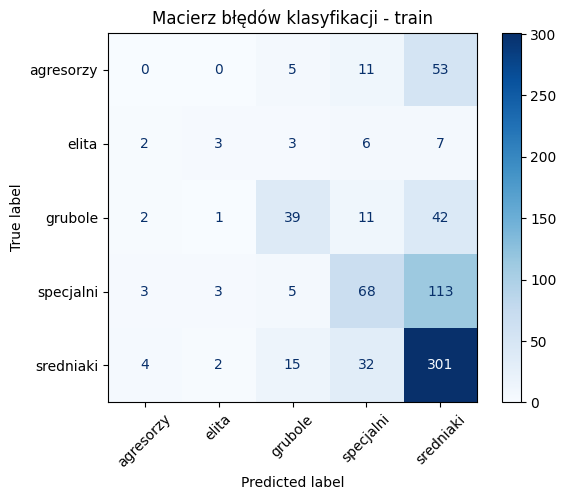

In [16]:
predykcja_train_regresja = modelRegresja.predict(cecha_train)
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_train,
    predykcja_train_regresja,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - train")
plt.savefig("confusion_matrix_train_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

#### 5.2.1. Dokładność modelu zbiór - testowy

In [17]:
predykcja_test_regresja = modelRegresja.predict(cecha_test)
print("Accuracy:", accuracy_score(etykieta_test, predykcja_test_regresja))
procent_poprawnych = accuracy_score(etykieta_test, predykcja_test_regresja) * 100
print(f"Procent poprawnych wyników: {procent_poprawnych:.2f}%")
f1_macro = f1_score(etykieta_test, predykcja_test_regresja, average="macro")
print(f"F1 macro: {f1_macro:.3f}")


Accuracy: 0.5477707006369427
Procent poprawnych wyników: 54.78%
F1 macro: 0.340


In [18]:
wyniki = cecha_test.copy()

wyniki["prawdziwa_grupa"] = etykieta_test.values
wyniki["przewidziana_grupa"] = predykcja_test_regresja

wyniki["pokemon"] = pokemonyMain.loc[cecha_test.index, "name"].values

print(wyniki[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))


               pokemon prawdziwa_grupa przewidziana_grupa
860            noivern       agresorzy          sredniaki
302             elekid       specjalni          sredniaki
698            gothita       specjalni          sredniaki
344            shiftry       sredniaki          sredniaki
1151          greavard       specjalni          sredniaki
1035          frosmoth       sredniaki          specjalni
455              bagon           elita            grubole
248             wooper       sredniaki          sredniaki
510     wormadam-sandy       sredniaki          sredniaki
616   samurott-hisuian       sredniaki          sredniaki
380           meditite       agresorzy          sredniaki
177              ditto       sredniaki          sredniaki
722         ferrothorn       sredniaki            grubole
320            torchic       specjalni          sredniaki
283            corsola       sredniaki          sredniaki
392             swalot       sredniaki          sredniaki
652           

#### 5.2.2. Macierz błędów klasyfikacji dla zbioru testowego


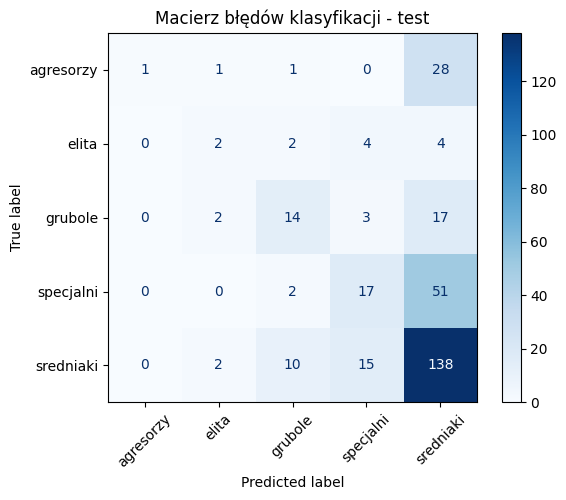

In [19]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    predykcja_test_regresja,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - test")
plt.savefig("confusion_matrix_test_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.3. Model drzewa


#### 5.3.1. Macierz błędów klasyfikacji dla zbioru treningowego

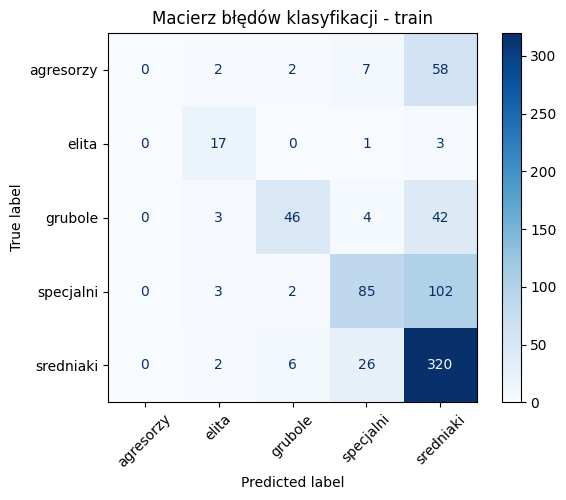

In [20]:
etykieta_pred_train_tree = tree_model.predict(cecha_train)
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_train,
    etykieta_pred_train_tree,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - train")
plt.savefig("confusion_matrix_train_drzewo.png", dpi=300, bbox_inches="tight")
plt.show()

#### 5.3.2 Dokładność modelu zbiór - testowy

In [21]:
etykieta_pred_tree = tree_model.predict(cecha_test)

In [22]:
print("Accuracy:", accuracy_score(etykieta_test, etykieta_pred_tree))
procent = accuracy_score(etykieta_test, etykieta_pred_tree) * 100
print(f"Procent poprawnych wyników: {procent:.2f}%")
f1_macro = f1_score(etykieta_test, etykieta_pred_tree, average="macro")
print(f"F1 macro: {f1_macro:.3f}")


Accuracy: 0.5636942675159236
Procent poprawnych wyników: 56.37%
F1 macro: 0.388


In [23]:
wyniki = cecha_test.copy()

wyniki["prawdziwa_grupa"] = etykieta_test.values
wyniki["przewidziana_grupa"] = etykieta_pred_tree

wyniki["pokemon"] = pokemonyMain.loc[
    etykieta_test.index,
    "name"
].values

print(
    wyniki[
        ["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]
    ].head(20)
)

               pokemon prawdziwa_grupa przewidziana_grupa
860            noivern       agresorzy          sredniaki
302             elekid       specjalni          specjalni
698            gothita       specjalni          sredniaki
344            shiftry       sredniaki          sredniaki
1151          greavard       specjalni          sredniaki
1035          frosmoth       sredniaki          sredniaki
455              bagon           elita              elita
248             wooper       sredniaki          sredniaki
510     wormadam-sandy       sredniaki            grubole
616   samurott-hisuian       sredniaki          sredniaki
380           meditite       agresorzy          sredniaki
177              ditto       sredniaki          sredniaki
722         ferrothorn       sredniaki            grubole
320            torchic       specjalni          sredniaki
283            corsola       sredniaki          sredniaki
392             swalot       sredniaki          sredniaki
652           

#### 5.3.3. Macierz błędów klasyfikacji dla zbioru testowego

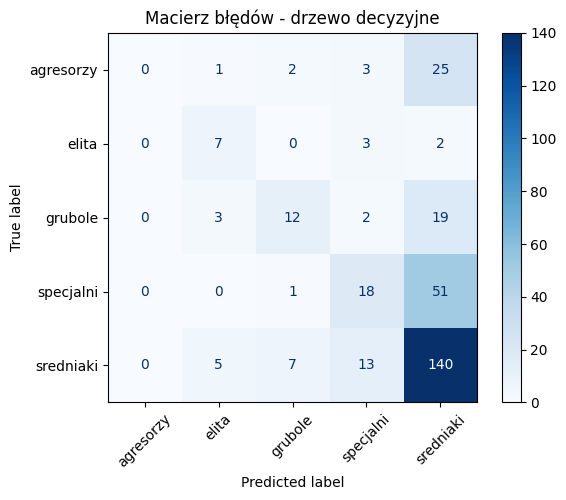

In [24]:
ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    etykieta_pred_tree,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów - drzewo decyzyjne")
plt.savefig("confusion_matrix_test_drzewo.png", dpi=300, bbox_inches="tight")
plt.show()

#### 5.3.4 Wizualizacja drzewa decyzyjnego

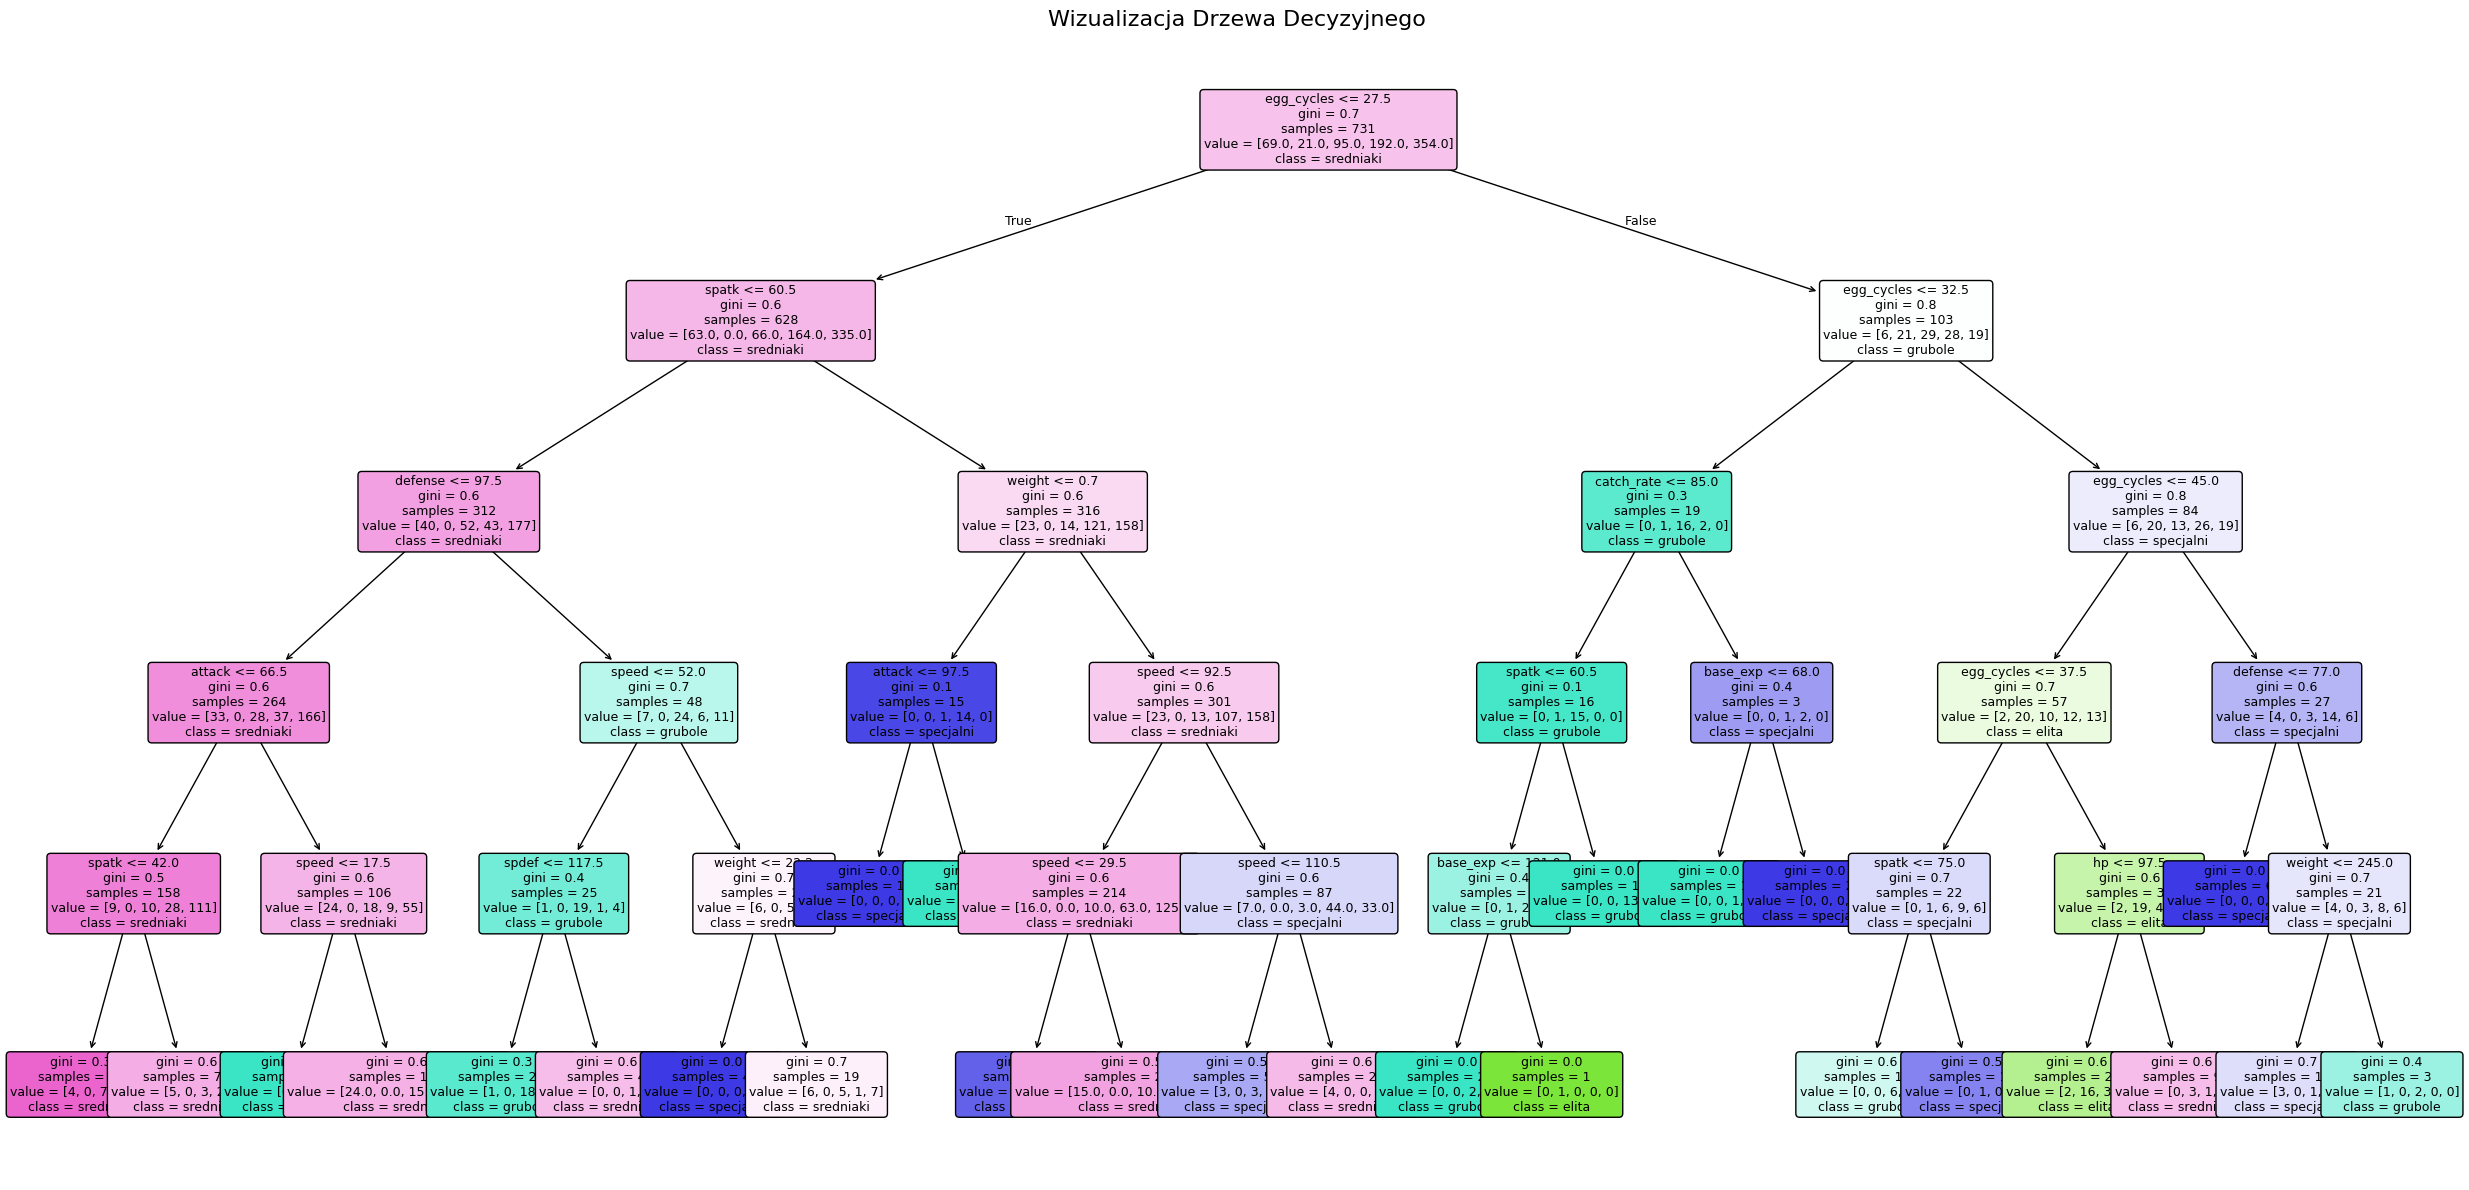

In [25]:
plt.figure(figsize=(25, 12))

annotations = plot_tree(
    tree_model,
    feature_names=cechy_names_without_group,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    precision=1
)

for text in annotations:
    text.set_color("black")

plt.title("Wizualizacja Drzewa Decyzyjnego", fontsize=16)
plt.tight_layout()

plt.savefig("wizualizacja_drzewo_decyzyjne.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### 5.4. Random Forest

#### 5.4.1. Macierz błędów klasyfikacji dla zbioru treningowego

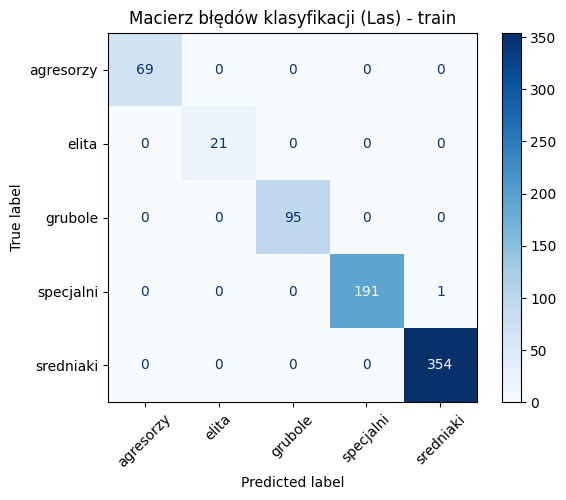

In [26]:
predykcja_train_las = modelLas.predict(cecha_train)
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_train,
    predykcja_train_las,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji (Las) - train")
plt.savefig("confusion_matrix_train_las.png", dpi=300, bbox_inches="tight")
plt.show()

#### 5.4.2. Dokładność modelu zbiór - testowy

In [27]:
predykcja_test_las = modelLas.predict(cecha_test)
print("Dokladnosc:", accuracy_score(etykieta_test, predykcja_test_las))
procent_poprawnych = accuracy_score(etykieta_test, predykcja_test_las) * 100
print(f"Procent poprawnych wyników: {procent_poprawnych:.2f}%")
f1_macro = f1_score(etykieta_test, hybrid3_pred, average="macro")
print(f"F1 macro:       {f1_macro:.3f}")

Dokladnosc: 0.5859872611464968
Procent poprawnych wyników: 58.60%
F1 macro:       0.443


In [28]:
wyniki = cecha_test.copy()

wyniki["prawdziwa_grupa"] = etykieta_test.values
wyniki["przewidziana_grupa"] = predykcja_test_las

wyniki["pokemon"] = pokemonyMain.loc[cecha_test.index, "name"].values

print(wyniki[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))

               pokemon prawdziwa_grupa przewidziana_grupa
860            noivern       agresorzy          sredniaki
302             elekid       specjalni          sredniaki
698            gothita       specjalni          sredniaki
344            shiftry       sredniaki          sredniaki
1151          greavard       specjalni            grubole
1035          frosmoth       sredniaki          specjalni
455              bagon           elita              elita
248             wooper       sredniaki          sredniaki
510     wormadam-sandy       sredniaki          sredniaki
616   samurott-hisuian       sredniaki          sredniaki
380           meditite       agresorzy          sredniaki
177              ditto       sredniaki          sredniaki
722         ferrothorn       sredniaki            grubole
320            torchic       specjalni          sredniaki
283            corsola       sredniaki          sredniaki
392             swalot       sredniaki          sredniaki
652           

#### 5.4.3. Macierz błędów klasyfikacji dla zbioru testowego

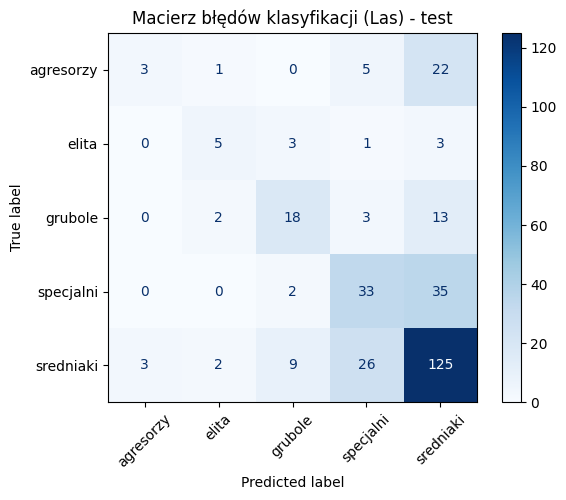

In [29]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    predykcja_test_las,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji (Las) - test")
plt.savefig("confusion_matrix_test_las.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.5. Model Hybrydowy

#### 5.5.1. Dokładność modelu zbiór - testowy

In [30]:
trafnosc = accuracy_score(etykieta_test, hybrid3_pred)
avg_pewn = srednia_aryt.max(axis=1).mean()
f1_macro = f1_score(etykieta_test, hybrid3_pred, average="macro")

print(f"Trafność:       {trafnosc * 100:.2f}%")
print(f"Średnia pewność: {avg_pewn:.3f}")
print(f"F1 macro:       {f1_macro:.3f}")

Trafność:       60.19%
Średnia pewność: 0.559
F1 macro:       0.443


In [31]:
wyniki3 = cecha_test.copy()

wyniki3["prawdziwa_grupa"] = etykieta_test.values
wyniki3["przewidziana_grupa"] = hybrid3_pred

wyniki3["pokemon"] = pokemonyMain.loc[cecha_test.index, "name"].values

print(wyniki3[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))

               pokemon prawdziwa_grupa przewidziana_grupa
860            noivern       agresorzy          sredniaki
302             elekid       specjalni          specjalni
698            gothita       specjalni          sredniaki
344            shiftry       sredniaki          sredniaki
1151          greavard       specjalni          sredniaki
1035          frosmoth       sredniaki          sredniaki
455              bagon           elita              elita
248             wooper       sredniaki          sredniaki
510     wormadam-sandy       sredniaki          sredniaki
616   samurott-hisuian       sredniaki          sredniaki
380           meditite       agresorzy          sredniaki
177              ditto       sredniaki          sredniaki
722         ferrothorn       sredniaki            grubole
320            torchic       specjalni          sredniaki
283            corsola       sredniaki          sredniaki
392             swalot       sredniaki          sredniaki
652           

#### 5.5.2. Macierz błędów klasyfikacji dla zbioru testowego

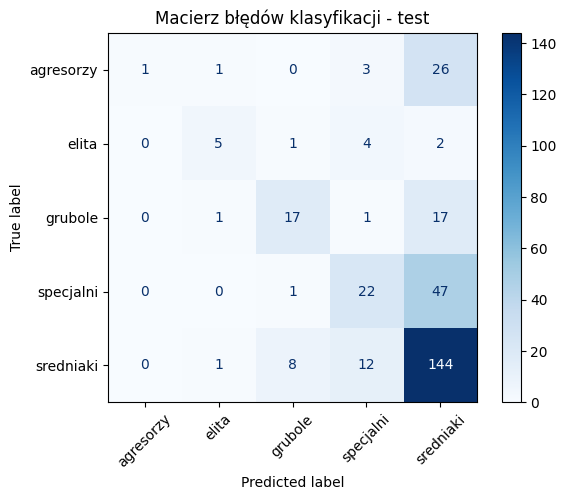

In [32]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    hybrid3_pred,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - test")
plt.savefig("confusion_matrix_test_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.6 Wnioski:


1. Regresja logistyczna:

Regresja logistyczna uzyskała najniższą dokładność spośród modeli pojedynczych. Jej accuracy jest umiarkowane, ale F1 macro wypada wyraźnie słabiej. Oznacza to, że model stosunkowo dobrze radzi sobie z częścią klas, ale gorzej rozpoznaje mniejsze i trudniejsze grupy.
Możliwa przyczyna: regresja logistyczna lepiej działa przy zależnościach liniowych, a dane Pokemonów mają bardziej złożoną strukturę i nierówny rozkład klas.

2. Drzewo decyzyjne:

Drzewo decyzyjne osiągnęło wynik zbliżony do regresji logistycznej, ale nadal słabszy niż las losowy. Accuracy nie jest wysokie, a F1 macro również pozostaje niskie.
Możliwa przyczyna: pojedyncze drzewo łatwo dopasowuje się do konkretnych reguł i może być niestabilne, przez co gorzej generalizuje na zbiorze testowym.

3. Las losowy:

Las losowy wypadł najlepiej spośród pojedynczych modeli. Zarówno accuracy, jak i F1 macro są wyższe niż w regresji logistycznej i drzewie decyzyjnym.
Możliwa przyczyna: las losowy łączy wiele drzew, dzięki czemu jest stabilniejszy i lepiej radzi sobie z nieliniowymi zależnościami oraz bardziej złożonymi cechami danych.

4. Model hybrydowy:

Wynik około 60% dla modelu hybrydowego jest wyższy niż dla pozostałych modeli, ponieważ hybryda łączy predykcje kilku klasyfikatorów i dzięki temu częściowo kompensuje ich indywidualne błędy. Każdy model patrzy na dane z nieco innej perspektywy: regresja logistyczna dobrze łapie zależności liniowe, las losowy radzi sobie z bardziej złożonymi relacjami, a drzewo decyzyjne dzieli dane według prostych reguł.
Gdy prawdopodobieństwa z tych modeli są uśredniane, końcowa decyzja staje się bardziej stabilna niż w przypadku pojedynczego klasyfikatora. W praktyce oznacza to, że jeśli jeden model się myli, pozostałe mogą „przeciągnąć” wynik w dobrą stronę. Dlatego hybryda może osiągnąć lepszą trafność niż każdy z modeli osobno.

5. Macierze:

Analiza macierzy błędów pokazuje, że najwięcej pomyłek występuje w klasie sredniaki. Wynika to z jej dużej liczebności oraz z faktu, że wiele Pokemonów z innych grup ma cechy podobne właśnie do tej klasy. Spośród pojedynczych modeli najlepiej wypada las losowy, natomiast model hybrydowy daje najbardziej stabilne i zrównoważone wyniki, choć nadal nie eliminuje wszystkich błędów klasyfikacji.

6. F1 Score:

Różnice między accuracy i F1 pokazują, że problem klasyfikacji jest trudniejszy dla mniej licznych klas, dlatego sama dokładność nie oddaje w pełni jakości modeli.


## 6. Sztuczna obserwacja

Wprowadzenie sztucznej obserwacji (tzw. obiektu syntetycznego) polega na przetestowaniu ostatecznej wersji algorytmu na całkowicie nowym, hipotetycznym obiekcie, który nie występował w pierwotnym zbiorze danych. Na potrzeby tej weryfikacji zdefiniowano unikalny profil Pokemona o sprecyzowanych, autorskich statystykach bojowych oraz parametrach rozwoju. Operacja ta pozwala zasymulować realne działanie modelu w warunkach produkcyjnych oraz ocenić, czy algorytm podejmuje logiczne decyzje klasyfikacyjne w zderzeniu z nowymi, nieznanymi wcześniej strukturami danych, co bezpośrednio realizuje praktyczne założenia projektu.

Tworzymy sztucznego pokemona o statystykach:
    hp: 90,
    attack: 110,
    defense: 80,
    spatk: 100,
    spdef: 85,
    speed: 95,
    height: 1.6,
    weight: 65.0,
    catch_rate: 45.0,
    base_exp: 240.0,
    egg_cycles: 25.0

In [33]:
sztuczny_pokemon = pd.DataFrame([{
    "hp": 90,
    "attack": 110,
    "defense": 80,
    "spatk": 100,
    "spdef": 85,
    "speed": 95,
    "height": 1.6,
    "weight": 65.0,
    "catch_rate": 45.0,
    "base_exp": 240.0,
    "egg_cycles": 25.0
}])

model_synth = {
    'LR': modelRegresja,
    'RF': modelLas,
    'DT': tree_model,
}

for key, model in model_synth.items():
    klasa_sztuczna = model.predict(sztuczny_pokemon)
    prawdopodobienstwa = model.predict_proba(sztuczny_pokemon)
    
    print(f"Klasyfikacja sztucznego Pokemona przez model {key}: {klasa_sztuczna[0]}")
    print("Prawdopodobieństwa przypisania do grup:")
    for klasa, prob in zip(modelLas.classes_, prawdopodobienstwa[0]):
        print(f" - {klasa}: {prob*100:.2f}%")

# Hybryda
lr_prob = modelRegresja.predict_proba(sztuczny_pokemon)[0]
rf_prob = modelLas.predict_proba(sztuczny_pokemon)[0]
dt_prob = tree_model.predict_proba(sztuczny_pokemon)[0]
srednia = (lr_prob + rf_prob + dt_prob) / 3
hybrid_pred_synth = grupy[np.argmax(srednia)]

print(f"Klasyfikacja sztucznego Pokemona przez model HB: {hybrid_pred_synth}")
print("Prawdopodobieństwa przypisania do grup:")
for i, grupa in enumerate(grupy):
    print(f" - {grupa}: {srednia[i]*100:.3f}%")

Klasyfikacja sztucznego Pokemona przez model LR: sredniaki
Prawdopodobieństwa przypisania do grup:
 - agresorzy: 12.36%
 - elita: 1.78%
 - grubole: 4.37%
 - specjalni: 33.74%
 - sredniaki: 47.75%
Klasyfikacja sztucznego Pokemona przez model RF: specjalni
Prawdopodobieństwa przypisania do grup:
 - agresorzy: 7.00%
 - elita: 1.00%
 - grubole: 4.00%
 - specjalni: 54.00%
 - sredniaki: 34.00%
Klasyfikacja sztucznego Pokemona przez model DT: specjalni
Prawdopodobieństwa przypisania do grup:
 - agresorzy: 5.17%
 - elita: 0.00%
 - grubole: 5.17%
 - specjalni: 60.34%
 - sredniaki: 29.31%
Klasyfikacja sztucznego Pokemona przez model HB: specjalni
Prawdopodobieństwa przypisania do grup:
 - agresorzy: 8.178%
 - elita: 0.926%
 - grubole: 4.515%
 - specjalni: 49.362%
 - sredniaki: 37.019%


## Biblliografia
- Mudireddy, Patibandla (2026). *PokeRL: Reinforcement Learning for Pokemon Red* [arxiv:2604.10812](https://arxiv.org/abs/2604.10812)

- Pleines et al. (2025). *Pokemon Red via Reinforcement Learning*, preprint [arxiv:2502.19920](https://arxiv.org/abs/2502.19920)

- Kilpatrick, Ćwiek, Kawahara (2023). *Random forests, sound symbolism and Pokemon evolution*, preprint [arxiv:2301.01948](https://arxiv.org/abs/2301.01948)

- Jackowska, Beata (2011). *Efekty interakcji między zmiennymi objaśniającymi w modelu logitowym w analizie zróżnicowania ryzyka zgonu*, Przegląd Statystyczny, R. LVIII, z. 1–2

- Zięba, M. (2019). *Modele liniowe* [materiały dydaktyczne, wykład RO_W4]. Politechnika Wrocławska

- Skrypt z wykładów Politechniki Warszawskiej: Cichosz, *Uczenie maszynowe: Drzewa decyzyjne*

- Skrypt z wykładów Uniwersytetu Warszawskiego: Nguyen *Eksploracja Danych: Drzewa decyzyjne*

- Materiały dydaktyczne Politechniki Wrocławskiej: Paluszyński, *Sztuczna Inteligencja: Drzewa decyzyjne*

- Breiman, L. (2001). Random Forests. *Machine Learning*, https://doi.org/10.1023/A:1010933404324

- https://www.listendata.com/2014/11/random-forest-with-r.html - definicja i działanie lasu losowego

- prezentacja: Wykład 6 - Wzmacnianie klasyfikatorów
dr hab. Konrad Furmańczyk, prof. SGGW, Instytut Informatyki Technicznej, November 9, 2021
